# On Analyzing Real World Time Series for Forecasting Wesad Heart Rate Data

In [1]:
import os
import sys

import numpy as np
import pandas as pd
# Get the current working directory of the notebook
notebook_dir = os.getcwd()

# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../../framework_for_time_series_data/tslearn/'))

In [2]:
pd.set_option('max_colwidth', 800)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
base_path = "../datasets/WESAD"

path = "/Users/detraviousjamaribrinkley/Documents/Development/startups/roeh-health/data/WESAD/S2/S2.pkl"
# print(f"Path: {path}")

data = pd.read_pickle(path)
data

{'signal': {'chest': {'ACC': array([[ 0.95539999, -0.222     , -0.55799997],
          [ 0.92579997, -0.2216    , -0.55379999],
          [ 0.90820003, -0.21960002, -0.53920001],
          ...,
          [ 0.87179995, -0.12379998, -0.30419999],
          [ 0.87300003, -0.12339997, -0.30260003],
          [ 0.87020004, -0.12199998, -0.30220002]]),
   'ECG': array([[ 0.02142334],
          [ 0.02032471],
          [ 0.01652527],
          ...,
          [-0.00544739],
          [ 0.00013733],
          [ 0.0040741 ]]),
   'EMG': array([[-0.00444031],
          [ 0.00434875],
          [ 0.00517273],
          ...,
          [-0.01716614],
          [-0.02897644],
          [-0.02357483]]),
   'EDA': array([[5.25054932],
          [5.26733398],
          [5.24330139],
          ...,
          [0.36048889],
          [0.36582947],
          [0.365448  ]]),
   'Temp': array([[30.120758],
          [30.129517],
          [30.138214],
          ...,
          [31.459229],
          [31.484283

In [4]:
def nested_dict_to_df(data):
    chest_acc = pd.DataFrame(data['signal']['chest']['ACC'], columns=['ACC_x', 'ACC_y', 'ACC_z'])
    chest_ecg = pd.DataFrame(data['signal']['chest']['ECG'], columns=['ECG'])
    chest_emg = pd.DataFrame(data['signal']['chest']['EMG'], columns=['EMG'])
    chest_eda = pd.DataFrame(data['signal']['chest']['EDA'], columns=['EDA'])
    chest_temp = pd.DataFrame(data['signal']['chest']['Temp'], columns=['Temp'])
    chest_resp = pd.DataFrame(data['signal']['chest']['Resp'], columns=['Resp'])
    
    # Combine all DataFrames
    df_chest = pd.concat([chest_acc, chest_ecg, chest_emg, chest_eda, chest_temp, chest_resp], axis=1)
    
    # Ensure labels and subject match the length of the DataFrame
    df_chest['label'] = np.repeat(data['label'], len(df_chest)) if len(data['label']) == 1 else data['label']
    df_chest['subject'] = data['subject']

    return df_chest

In [5]:
# Create DataFrames
df_chest = nested_dict_to_df(data)

In [6]:
# Display DataFrames
print("Chest DataFrame:")
df_chest.head(7)

Chest DataFrame:


,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,label,subject
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,0,S2
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,0,S2
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,0,S2
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,0,S2
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130951,-1.161194,0,S2
5,0.8822,-0.1954,-0.4454,0.004898,-0.016479,5.251694,30.125153,-1.165771,0,S2
6,0.8760,-0.1866,-0.4144,0.002792,-0.004578,5.262756,30.207947,-1.129150,0,S2


<Axes: >

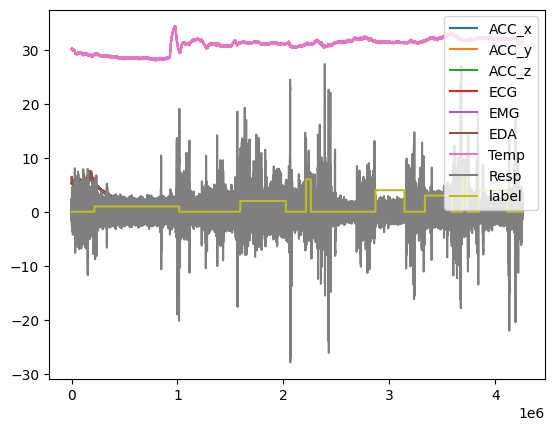

In [7]:
df_chest.plot()